<a href="https://colab.research.google.com/github/aabyyaann/scikit-learn-Cookbook/blob/main/Chapter3_Dictionaries_and_Text_Feature_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 - Dictionaries and Text Feature Extraction

Notebook ini merangkum Chapter 3 dari **scikit-learn Cookbook**.  
Fokus chapter ini adalah bagaimana mengubah data mentah yang masih berbentuk **teks** atau **dictionary** menjadi **fitur numerik** yang dapat diproses oleh model machine learning.

Topik utama yang dibahas:
- representasi data kategorikal menggunakan dictionary,
- ekstraksi fitur dengan **DictVectorizer**,
- ekstraksi fitur teks dengan **CountVectorizer**,
- penggunaan **TF-IDF**,
- pemakaian **n-gram**,
- melihat vocabulary dan bentuk matriks fitur,
- serta memahami kapan pendekatan tertentu lebih cocok digunakan.

Chapter ini penting karena sebagian besar algoritma machine learning tidak dapat langsung menerima teks mentah.  
Sebelum model dibangun, teks harus diubah terlebih dahulu menjadi representasi numerik yang tetap mempertahankan informasi penting dari data aslinya.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Library berhasil di-load.")

Library berhasil di-load.


## 1. Gambaran Umum Chapter

Pada machine learning, data sering kali tidak langsung berbentuk angka.  
Ada dua kasus yang sangat umum:

1. **Data kategorikal / structured data**  
   Contohnya:
   - warna produk,
   - kota pelanggan,
   - tipe membership,
   - jenis perangkat.

   Data seperti ini sering direpresentasikan sebagai **dictionary** lalu diubah menjadi fitur numerik.

2. **Data teks bebas / unstructured text**  
   Contohnya:
   - review film,
   - komentar pelanggan,
   - email,
   - judul berita.

   Data seperti ini biasanya diubah menjadi representasi numerik menggunakan:
   - **bag-of-words**
   - **count vector**
   - **TF-IDF**
   - **n-gram**

Chapter ini memperkenalkan cara praktis untuk mengubah kedua jenis data tersebut menjadi format yang bisa dipakai oleh model scikit-learn.

## 2. Contoh Data Kategorikal dalam Bentuk Dictionary

Kita mulai dari data terstruktur sederhana.  
Misalnya kita memiliki informasi pelanggan toko online dengan fitur kategorikal seperti:
- kota,
- membership,
- perangkat yang dipakai.

Alih-alih langsung memakai DataFrame, kita akan melihat bagaimana data seperti ini bisa direpresentasikan dalam bentuk **list of dictionaries**.

In [2]:
customer_dicts = [
    {"city": "Jakarta", "membership": "Gold", "device": "Mobile"},
    {"city": "Bandung", "membership": "Silver", "device": "Desktop"},
    {"city": "Surabaya", "membership": "Gold", "device": "Tablet"},
    {"city": "Jakarta", "membership": "Platinum", "device": "Mobile"},
    {"city": "Bandung", "membership": "Gold", "device": "Mobile"},
]

customer_dicts

[{'city': 'Jakarta', 'membership': 'Gold', 'device': 'Mobile'},
 {'city': 'Bandung', 'membership': 'Silver', 'device': 'Desktop'},
 {'city': 'Surabaya', 'membership': 'Gold', 'device': 'Tablet'},
 {'city': 'Jakarta', 'membership': 'Platinum', 'device': 'Mobile'},
 {'city': 'Bandung', 'membership': 'Gold', 'device': 'Mobile'}]

## 3. Mengubah Dictionary menjadi Fitur Numerik dengan DictVectorizer

`DictVectorizer` digunakan untuk mengubah kumpulan dictionary menjadi matriks fitur numerik.  
Secara konsep, ia akan melakukan proses mirip **one-hot encoding** untuk nilai kategorikal.

Contoh:
- `city=Jakarta`
- `membership=Gold`
- `device=Mobile`

akan diubah menjadi kolom-kolom fitur biner seperti:
- city=Bandung
- city=Jakarta
- city=Surabaya
- membership=Gold
- membership=Platinum
- membership=Silver
- device=Desktop
- device=Mobile
- device=Tablet

In [3]:
dict_vec = DictVectorizer(sparse=False)
X_dict = dict_vec.fit_transform(customer_dicts)

print("Shape matriks fitur:", X_dict.shape)
print("\nNama fitur:")
print(dict_vec.get_feature_names_out())
print("\nMatriks fitur:")
print(X_dict)

Shape matriks fitur: (5, 9)

Nama fitur:
['city=Bandung' 'city=Jakarta' 'city=Surabaya' 'device=Desktop'
 'device=Mobile' 'device=Tablet' 'membership=Gold' 'membership=Platinum'
 'membership=Silver']

Matriks fitur:
[[0. 1. 0. 0. 1. 0. 1. 0. 0.]
 [1. 0. 0. 1. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 1. 1. 0. 0.]
 [0. 1. 0. 0. 1. 0. 0. 1. 0.]
 [1. 0. 0. 0. 1. 0. 1. 0. 0.]]


In [4]:
df_dict_features = pd.DataFrame(X_dict, columns=dict_vec.get_feature_names_out())
df_dict_features

,city=Bandung,city=Jakarta,city=Surabaya,device=Desktop,device=Mobile,device=Tablet,membership=Gold,membership=Platinum,membership=Silver
0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


## 4. Interpretasi Hasil DictVectorizer

Hasil di atas menunjukkan bahwa setiap kategori dipecah menjadi kolom fitur tersendiri.  
Nilai pada kolom tersebut akan bernilai:
- **1** jika data memiliki kategori itu,
- **0** jika tidak.

Pendekatan ini sangat berguna karena sebagian besar model machine learning membutuhkan input numerik, sedangkan data kategorikal tidak bisa dipakai secara langsung.

## 5. Dictionary dengan Fitur Numerik dan Kategorikal Sekaligus

Dalam praktik nyata, dictionary tidak selalu hanya berisi kategori.  
Sering kali ada kombinasi antara:
- fitur numerik, misalnya `age` atau `income`
- fitur kategorikal, misalnya `city` atau `membership`

`DictVectorizer` bisa menangani keduanya sekaligus.

In [5]:
customer_dicts_mixed = [
    {"city": "Jakarta", "membership": "Gold", "age": 25, "spending": 70},
    {"city": "Bandung", "membership": "Silver", "age": 31, "spending": 60},
    {"city": "Surabaya", "membership": "Gold", "age": 28, "spending": 80},
    {"city": "Jakarta", "membership": "Platinum", "age": 40, "spending": 95},
]

dict_vec_mixed = DictVectorizer(sparse=False)
X_mixed = dict_vec_mixed.fit_transform(customer_dicts_mixed)

df_mixed = pd.DataFrame(X_mixed, columns=dict_vec_mixed.get_feature_names_out())
df_mixed

,age,city=Bandung,city=Jakarta,city=Surabaya,membership=Gold,membership=Platinum,membership=Silver,spending
0,25.0,0.0,1.0,0.0,1.0,0.0,0.0,70.0
1,31.0,1.0,0.0,0.0,0.0,0.0,1.0,60.0
2,28.0,0.0,0.0,1.0,1.0,0.0,0.0,80.0
3,40.0,0.0,1.0,0.0,0.0,1.0,0.0,95.0


## 6. Beralih ke Data Teks

Setelah melihat data kategorikal berbentuk dictionary, sekarang kita masuk ke data teks.  
Teks mentah tidak bisa langsung dipakai oleh model karena model membutuhkan angka.

Salah satu pendekatan paling dasar adalah **bag-of-words**:
- setiap kata unik dianggap sebagai fitur,
- nilai fitur menunjukkan apakah kata itu muncul atau berapa kali muncul.

Representasi ini bisa dibuat menggunakan `CountVectorizer`.

In [6]:
documents = [
    "machine learning is fun",
    "python makes machine learning easier",
    "data science uses machine learning",
    "deep learning is part of machine learning",
    "python is useful for data science"
]

documents

['machine learning is fun',
 'python makes machine learning easier',
 'data science uses machine learning',
 'deep learning is part of machine learning',
 'python is useful for data science']

## 7. CountVectorizer

`CountVectorizer` mengubah sekumpulan dokumen teks menjadi matriks angka berdasarkan jumlah kemunculan kata.

Langkah sederhananya:
1. memecah teks menjadi token/kata,
2. membuat vocabulary dari seluruh kata unik,
3. menghitung frekuensi kemunculan kata pada tiap dokumen.

Hasilnya adalah matriks:
- baris = dokumen,
- kolom = kata dalam vocabulary,
- isi = jumlah kemunculan kata.

In [7]:
count_vec = CountVectorizer()
X_counts = count_vec.fit_transform(documents)

print("Shape matriks:", X_counts.shape)
print("\nVocabulary:")
print(count_vec.get_feature_names_out())

Shape matriks: (5, 15)

Vocabulary:
['data' 'deep' 'easier' 'for' 'fun' 'is' 'learning' 'machine' 'makes' 'of'
 'part' 'python' 'science' 'useful' 'uses']


In [8]:
df_counts = pd.DataFrame(
    X_counts.toarray(),
    columns=count_vec.get_feature_names_out()
)
df_counts

,data,deep,easier,for,fun,is,learning,machine,makes,of,part,python,science,useful,uses
0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0
1,0,0,1,0,0,0,1,1,1,0,0,1,0,0,0
2,1,0,0,0,0,0,1,1,0,0,0,0,1,0,1
3,0,1,0,0,0,1,2,1,0,1,1,0,0,0,0
4,1,0,0,1,0,1,0,0,0,0,0,1,1,1,0


## 8. Interpretasi Count Matrix

Matriks count di atas menunjukkan berapa kali sebuah kata muncul pada masing-masing dokumen.

Contoh:
- jika kata **machine** muncul satu kali pada dokumen pertama, maka nilai kolom `machine` untuk dokumen pertama adalah 1.
- jika kata tidak muncul sama sekali, nilainya 0.

Representasi ini sederhana dan sering menjadi baseline awal dalam text mining.

In [9]:
vocab_mapping = count_vec.vocabulary_
vocab_mapping

{'machine': 7,
 'learning': 6,
 'is': 5,
 'fun': 4,
 'python': 11,
 'makes': 8,
 'easier': 2,
 'data': 0,
 'science': 12,
 'uses': 14,
 'deep': 1,
 'part': 10,
 'of': 9,
 'useful': 13,
 'for': 3}

## 9. Mengabaikan Kata yang Terlalu Umum dengan Stop Words

Beberapa kata terlalu umum dan kurang informatif, misalnya:
- "the"
- "is"
- "and"

Kata-kata seperti ini sering disebut **stop words**.  
Dalam beberapa kasus, menghapus stop words dapat membantu fokus pada kata yang lebih penting.

In [10]:
count_vec_sw = CountVectorizer(stop_words="english")
X_counts_sw = count_vec_sw.fit_transform(documents)

print("Vocabulary tanpa stop words:")
print(count_vec_sw.get_feature_names_out())

df_counts_sw = pd.DataFrame(
    X_counts_sw.toarray(),
    columns=count_vec_sw.get_feature_names_out()
)
df_counts_sw

Vocabulary tanpa stop words:
['data' 'deep' 'easier' 'fun' 'learning' 'machine' 'makes' 'python'
 'science' 'useful' 'uses']


,data,deep,easier,fun,learning,machine,makes,python,science,useful,uses
0,0,0,0,1,1,1,0,0,0,0,0
1,0,0,1,0,1,1,1,1,0,0,0
2,1,0,0,0,1,1,0,0,1,0,1
3,0,1,0,0,2,1,0,0,0,0,0
4,1,0,0,0,0,0,0,1,1,1,0


## 10. Membatasi Kata dengan min_df

Tidak semua kata perlu dimasukkan ke vocabulary.  
Kata yang sangat jarang muncul kadang hanya menambah noise.

Parameter `min_df` digunakan untuk menyaring kata yang terlalu jarang muncul.
Contoh:
- `min_df=2` berarti hanya kata yang muncul minimal di 2 dokumen yang akan dipertahankan.

In [11]:
count_vec_min = CountVectorizer(min_df=2)
X_counts_min = count_vec_min.fit_transform(documents)

print("Vocabulary dengan min_df=2:")
print(count_vec_min.get_feature_names_out())

df_counts_min = pd.DataFrame(
    X_counts_min.toarray(),
    columns=count_vec_min.get_feature_names_out()
)
df_counts_min

Vocabulary dengan min_df=2:
['data' 'is' 'learning' 'machine' 'python' 'science']


,data,is,learning,machine,python,science
0,0,1,1,1,0,0
1,0,0,1,1,1,0
2,1,0,1,1,0,1
3,0,1,2,1,0,0
4,1,1,0,0,1,1


## 11. N-gram

Secara default, `CountVectorizer` hanya melihat kata tunggal (**unigram**).  
Namun, kadang informasi penting justru ada pada gabungan dua kata atau lebih, misalnya:
- "machine learning"
- "data science"

Untuk itu kita bisa memakai **n-gram**:
- unigram = 1 kata
- bigram = 2 kata
- trigram = 3 kata

In [12]:
count_vec_bigram = CountVectorizer(ngram_range=(1, 2))
X_bigram = count_vec_bigram.fit_transform(documents)

print("Jumlah fitur dengan unigram + bigram:", X_bigram.shape[1])
print("\nSebagian vocabulary:")
print(count_vec_bigram.get_feature_names_out()[:30])

Jumlah fitur dengan unigram + bigram: 32

Sebagian vocabulary:
['data' 'data science' 'deep' 'deep learning' 'easier' 'for' 'for data'
 'fun' 'is' 'is fun' 'is part' 'is useful' 'learning' 'learning easier'
 'learning is' 'machine' 'machine learning' 'makes' 'makes machine' 'of'
 'of machine' 'part' 'part of' 'python' 'python is' 'python makes'
 'science' 'science uses' 'useful' 'useful for']


In [13]:
df_bigram = pd.DataFrame(
    X_bigram.toarray(),
    columns=count_vec_bigram.get_feature_names_out()
)

df_bigram.iloc[:, :20]

,data,data science,deep,deep learning,easier,for,for data,fun,is,is fun,is part,is useful,learning,learning easier,learning is,machine,machine learning,makes,makes machine,of
0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,1,1,1,0,0,0
1,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,1,1,1,1,0
2,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0
3,0,0,1,1,0,0,0,0,1,0,1,0,2,0,1,1,1,0,0,1
4,1,1,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0


## 12. TF-IDF

CountVectorizer hanya menghitung frekuensi kata.  
Masalahnya, kata yang sering muncul di hampir semua dokumen bisa menjadi terlalu dominan, padahal belum tentu paling informatif.

Karena itu kita bisa memakai **TF-IDF** (*Term Frequency - Inverse Document Frequency*).

Ide dasarnya:
- kata yang sering muncul dalam satu dokumen akan mendapat bobot lebih tinggi,
- tetapi jika kata tersebut muncul di hampir semua dokumen, bobotnya akan diturunkan.

Dengan begitu, kata yang lebih khas untuk suatu dokumen menjadi lebih menonjol.

In [14]:
tfidf_vec = TfidfVectorizer()
X_tfidf = tfidf_vec.fit_transform(documents)

print("Shape matriks TF-IDF:", X_tfidf.shape)
print("\nVocabulary:")
print(tfidf_vec.get_feature_names_out())

Shape matriks TF-IDF: (5, 15)

Vocabulary:
['data' 'deep' 'easier' 'for' 'fun' 'is' 'learning' 'machine' 'makes' 'of'
 'part' 'python' 'science' 'useful' 'uses']


In [15]:
df_tfidf = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf_vec.get_feature_names_out()
)

df_tfidf.round(3)

,data,deep,easier,for,fun,is,learning,machine,makes,of,part,python,science,useful,uses
0,0.000,0.000,0.000,0.000,0.693,0.464,0.390,0.390,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.000,0.000,0.552,0.000,0.000,0.000,0.311,0.311,0.552,0.000,0.000,0.445,0.000,0.000,0.000
2,0.471,0.000,0.000,0.000,0.000,0.000,0.329,0.329,0.000,0.000,0.000,0.000,0.471,0.000,0.584
3,0.000,0.446,0.000,0.000,0.000,0.298,0.502,0.251,0.000,0.446,0.446,0.000,0.000,0.000,0.000
4,0.385,0.000,0.000,0.477,0.000,0.319,0.000,0.000,0.000,0.000,0.000,0.385,0.385,0.477,0.000


## 13. Membandingkan Count dan TF-IDF

Perbedaan utama:
- **CountVectorizer** menghasilkan jumlah kemunculan kata,
- **TfidfVectorizer** menghasilkan bobot kata.

TF-IDF sering lebih baik untuk klasifikasi teks karena:
- mengurangi pengaruh kata yang terlalu umum,
- menonjolkan kata yang lebih khas,
- dan biasanya memberikan representasi yang lebih informatif.

In [16]:
comparison_word = "machine"

if comparison_word in count_vec.get_feature_names_out() and comparison_word in tfidf_vec.get_feature_names_out():
    count_idx = list(count_vec.get_feature_names_out()).index(comparison_word)
    tfidf_idx = list(tfidf_vec.get_feature_names_out()).index(comparison_word)

    comparison_df = pd.DataFrame({
        "document": documents,
        "count_machine": X_counts.toarray()[:, count_idx],
        "tfidf_machine": X_tfidf.toarray()[:, tfidf_idx]
    })
    display(comparison_df)
else:
    print("Kata tidak ditemukan dalam vocabulary.")

,document,count_machine,tfidf_machine
0,machine learning is fun,1,0.390325
1,python makes machine learning easier,1,0.310805
2,data science uses machine learning,1,0.328760
3,deep learning is part of machine learning,1,0.251062
4,python is useful for data science,0,0.000000


## 14. Visualisasi Frekuensi Kata

Agar lebih mudah dibaca, kita bisa menghitung total frekuensi kata dari seluruh dokumen, lalu menampilkannya dalam bentuk bar chart.

In [17]:
word_counts = np.asarray(X_counts.sum(axis=0)).ravel()
words = count_vec.get_feature_names_out()

freq_df = pd.DataFrame({
    "word": words,
    "count": word_counts
}).sort_values("count", ascending=False)

freq_df

,word,count
6,learning,5
7,machine,4
5,is,3
11,python,2
12,science,2
0,data,2
2,easier,1
3,for,1
4,fun,1
1,deep,1


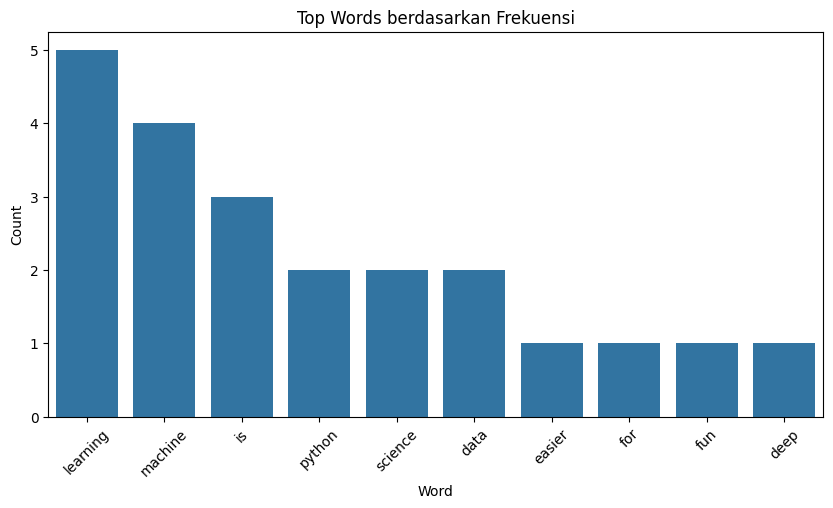

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(data=freq_df.head(10), x="word", y="count")
plt.title("Top Words berdasarkan Frekuensi")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 15. Visualisasi Bobot TF-IDF

Kita juga bisa menghitung rata-rata bobot TF-IDF untuk setiap kata di seluruh dokumen.  
Ini membantu melihat kata mana yang secara umum memiliki bobot informasi lebih tinggi.

In [19]:
tfidf_mean = np.asarray(X_tfidf.mean(axis=0)).ravel()
tfidf_words = tfidf_vec.get_feature_names_out()

tfidf_df = pd.DataFrame({
    "word": tfidf_words,
    "mean_tfidf": tfidf_mean
}).sort_values("mean_tfidf", ascending=False)

tfidf_df

,word,mean_tfidf
6,learning,0.306403
7,machine,0.256190
5,is,0.216333
12,science,0.171074
0,data,0.171074
11,python,0.165932
4,fun,0.138565
14,uses,0.116709
8,makes,0.110335
2,easier,0.110335


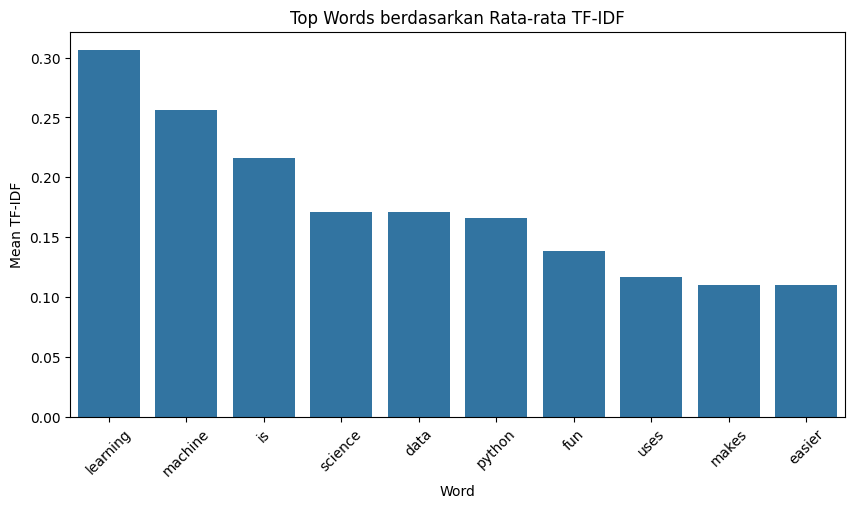

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(data=tfidf_df.head(10), x="word", y="mean_tfidf")
plt.title("Top Words berdasarkan Rata-rata TF-IDF")
plt.xlabel("Word")
plt.ylabel("Mean TF-IDF")
plt.xticks(rotation=45)
plt.show()

## 16. Contoh Data Teks untuk Klasifikasi Sederhana

Agar lebih terasa konteks machine learning-nya, kita buat dataset kecil berisi kalimat dan label sentimen sederhana:
- 1 = positif
- 0 = negatif

Tujuan di sini bukan membangun model yang kompleks, tetapi menunjukkan bagaimana hasil ekstraksi fitur teks akan menjadi input untuk model.

In [21]:
text_data = pd.DataFrame({
    "text": [
        "this movie is amazing and inspiring",
        "the film was boring and too long",
        "excellent acting and great story",
        "terrible movie and bad ending",
        "i love this film",
        "i hate this movie",
        "wonderful soundtrack and visuals",
        "the plot was weak and disappointing"
    ],
    "label": [1, 0, 1, 0, 1, 0, 1, 0]
})

text_data

,text,label
0,this movie is amazing and inspiring,1
1,the film was boring and too long,0
2,excellent acting and great story,1
3,terrible movie and bad ending,0
4,i love this film,1
5,i hate this movie,0
6,wonderful soundtrack and visuals,1
7,the plot was weak and disappointing,0


## 17. Mengubah Teks Berlabel menjadi Matriks Fitur

Sekarang kita ubah kolom teks menjadi fitur numerik menggunakan `CountVectorizer`.  
Hasilnya nanti bisa langsung diberikan ke model klasifikasi seperti Logistic Regression, Naive Bayes, atau SVM.

In [22]:
vectorizer_label = CountVectorizer()
X_text = vectorizer_label.fit_transform(text_data["text"])
y_text = text_data["label"]

print("Shape fitur:", X_text.shape)
print("Jumlah label:", y_text.shape[0])
print("\nVocabulary:")
print(vectorizer_label.get_feature_names_out())

Shape fitur: (8, 27)
Jumlah label: 8

Vocabulary:
['acting' 'amazing' 'and' 'bad' 'boring' 'disappointing' 'ending'
 'excellent' 'film' 'great' 'hate' 'inspiring' 'is' 'long' 'love' 'movie'
 'plot' 'soundtrack' 'story' 'terrible' 'the' 'this' 'too' 'visuals' 'was'
 'weak' 'wonderful']


In [23]:
df_text_features = pd.DataFrame(
    X_text.toarray(),
    columns=vectorizer_label.get_feature_names_out()
)

df_text_features

,acting,amazing,and,bad,boring,disappointing,ending,excellent,film,great,hate,inspiring,is,long,love,movie,plot,soundtrack,story,terrible,the,this,too,visuals,was,weak,wonderful
0,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0
1,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0
2,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
6,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1
7,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,1,0


## 18. Kapan Menggunakan DictVectorizer dan Kapan Menggunakan Text Vectorizer?

### DictVectorizer
Cocok untuk:
- data tabular / structured,
- fitur kategorikal berbentuk pasangan key-value,
- data yang mirip JSON / dictionary.

Contoh:
- `{"city": "Jakarta", "device": "Mobile"}`

### CountVectorizer / TfidfVectorizer
Cocok untuk:
- dokumen teks,
- review, komentar, email, berita,
- data unstructured text.

Contoh:
- `"machine learning is fun"`

Perbedaannya sederhana:
- **DictVectorizer** bekerja pada **fitur terstruktur**
- **CountVectorizer / TF-IDF** bekerja pada **teks bebas**

In [24]:
summary = pd.DataFrame({
    "Method": ["DictVectorizer", "CountVectorizer", "TfidfVectorizer"],
    "Input Type": [
        "Dictionary / structured categorical data",
        "Raw text documents",
        "Raw text documents"
    ],
    "Output": [
        "Numerical feature matrix (often one-hot style)",
        "Word count matrix",
        "Weighted TF-IDF matrix"
    ],
    "Main Use": [
        "Categorical/tabular feature encoding",
        "Basic text feature extraction",
        "Text representation with importance weighting"
    ]
})

summary

,Method,Input Type,Output,Main Use
0,DictVectorizer,Dictionary / structured categorical data,Numerical feature matrix (often one-hot style),Categorical/tabular feature encoding
1,CountVectorizer,Raw text documents,Word count matrix,Basic text feature extraction
2,TfidfVectorizer,Raw text documents,Weighted TF-IDF matrix,Text representation with importance weighting


## 19. Insight Utama dari Chapter 3

Chapter ini menekankan bahwa proses ekstraksi fitur adalah jembatan antara **data mentah** dan **model machine learning**.

Beberapa poin penting:
1. model machine learning membutuhkan input numerik,
2. data kategorikal bisa diubah dengan `DictVectorizer`,
3. data teks bisa diubah dengan `CountVectorizer`,
4. TF-IDF membantu memberi bobot lebih baik pada kata,
5. n-gram dapat menangkap konteks gabungan kata,
6. pemilihan representasi fitur sangat memengaruhi performa model di tahap berikutnya.

In [25]:
conclusion = [
    "DictVectorizer digunakan untuk mengubah dictionary menjadi fitur numerik.",
    "CountVectorizer mengubah dokumen teks menjadi matriks jumlah kata.",
    "TfidfVectorizer memberikan bobot pada kata berdasarkan kepentingannya dalam dokumen.",
    "N-gram membantu menangkap kombinasi kata, bukan hanya kata tunggal.",
    "Ekstraksi fitur adalah tahap penting sebelum data dipakai oleh model machine learning."
]

for i, point in enumerate(conclusion, start=1):
    print(f"{i}. {point}")

1. DictVectorizer digunakan untuk mengubah dictionary menjadi fitur numerik.
2. CountVectorizer mengubah dokumen teks menjadi matriks jumlah kata.
3. TfidfVectorizer memberikan bobot pada kata berdasarkan kepentingannya dalam dokumen.
4. N-gram membantu menangkap kombinasi kata, bukan hanya kata tunggal.
5. Ekstraksi fitur adalah tahap penting sebelum data dipakai oleh model machine learning.


## 20. Kesimpulan Chapter 3

Pada chapter ini, kita mempelajari dua kelompok besar teknik representasi fitur:

### 1. Representasi data kategorikal dengan dictionary
Data terstruktur seperti kota, membership, dan device dapat diubah menjadi fitur numerik menggunakan **DictVectorizer**.  
Pendekatan ini mirip one-hot encoding dan sangat berguna untuk data tabular dengan kategori.

### 2. Representasi data teks
Teks mentah dapat diubah menjadi fitur numerik menggunakan:
- **CountVectorizer** untuk menghitung jumlah kemunculan kata,
- **TfidfVectorizer** untuk memberi bobot kata berdasarkan kepentingannya,
- **n-gram** untuk menangkap kombinasi kata.

Inti dari chapter ini adalah bahwa kualitas representasi fitur sangat penting.  
Sebelum model dilatih, kita harus memastikan bahwa informasi dari data mentah sudah diubah menjadi bentuk numerik yang tetap mempertahankan pola penting dari data tersebut.

In [26]:
df_dict_features.to_csv("chapter3_dictvectorizer_output.csv", index=False)
df_counts.to_csv("chapter3_countvectorizer_output.csv", index=False)
df_tfidf.to_csv("chapter3_tfidf_output.csv", index=False)

print("Beberapa output chapter 3 berhasil disimpan.")

Beberapa output chapter 3 berhasil disimpan.
